# Clase 2. Modelo de regresión lineal simple

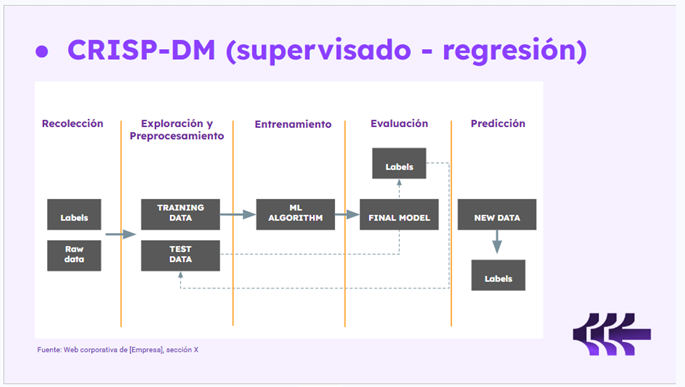

En este ejercicio vamos a trabajar un caso básico de predicción mediante regresión lineal simple. Para ello, no vamos a utilizar datos reales, sino que vamos a generar un conjunto de datos sintético.

Esto nos permite controlar completamente la relación entre las variables y entender mejor cómo aprende el modelo.



## Recolección de datos (Los vamos a crear nosotros/as)

En concreto, hemos generado los datos a partir de una función lineal, donde la variable dependiente y depende de x según una relación sencilla, a la que además le añadimos un pequeño ruido aleatorio -> f(x)=0.2x+1.25+ruido

Esto es importante, porque en la realidad los datos nunca son perfectos, siempre contienen variabilidad.

Además, utilizamos una semilla aleatoria para que el resultado sea reproducible, es decir, que todos obtengamos exactamente el mismo conjunto de datos.

A partir de ahí, generamos valores de x, calculamos y aplicando la función, y representamos los datos en un gráfico, donde podemos observar una tendencia lineal clara, aunque con cierta dispersión debido al ruido.

Finalmente, se representa el dataset mediante un gráfico de dispersión, donde se observa una tendencia lineal clara, aunque con cierta dispersión debida al ruido añadido.

## Fase de recoleccción de datos

In [5]:
# 1. librería numérica
import numpy as np

# librería para crear gráficos
import matplotlib.pyplot as plt


In [6]:
# 2. función f(x) = 0.2x + 1.25 + ruido gaussiano
def f(x):
    np.random.seed(42)  # para poder reproducirlo
    y = 0.2 * x + 1.25 + 0.2 * np.random.randn(x.shape[0])
    return y


In [7]:
# 3. generamos valores x de 0 a 20 en intervalos de 0.5
x = np.arange(0, 20, 0.5)

In [8]:

# 4. asignamos la función a la variable dependiente y
y = f(x)

## Fase de exploración (sencilla)

In [9]:
# 5. Visualizamos nuestro dataset en forma de tabla
import pandas as pd

data = pd.DataFrame({
    'x': x,
    'y': y
})

print(data)

       x         y
0    0.0  1.349343
1    0.5  1.322347
2    1.0  1.579538
3    1.5  1.854606
4    2.0  1.603169
5    2.5  1.703173
6    3.0  2.165843
7    3.5  2.103487
8    4.0  1.956105
9    4.5  2.258512
10   5.0  2.157316
11   5.5  2.256854
12   6.0  2.498392
13   6.5  2.167344
14   7.0  2.305016
15   7.5  2.637542
16   8.0  2.647434
17   8.5  3.012849
18   9.0  2.868395
19   9.5  2.867539
20  10.0  3.543130
21  10.5  3.304845
22  11.0  3.463506
23  11.5  3.265050
24  12.0  3.541123
25  12.5  3.772185
26  13.0  3.619801
27  13.5  4.025140
28  14.0  3.929872
29  14.5  4.091661
30  15.0  4.129659
31  15.5  4.720456
32  16.0  4.447301
33  16.5  4.338458
34  17.0  4.814509
35  17.5  4.505831
36  18.0  4.891773
37  18.5  4.558066
38  19.0  4.784363
39  19.5  5.189372


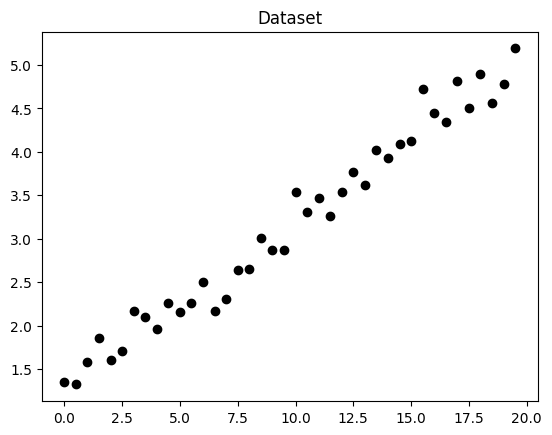

In [10]:
# 6. Visualizamos nuestro dataset gráficamente
plt.scatter(x, y, label = 'data', color= 'black')
plt.title('Dataset')
plt.show()

## Fase de entrenamiento

In [11]:
# Importamos la clase de Regresión Lineal de scikit-learn
from sklearn.linear_model import LinearRegression

In [13]:

# Creamos el objeto de regresión lineal
regresion_lineal = LinearRegression()

# Entrenamos el modelo con los datos (x, y)
regresion_lineal.fit(x.reshape(-1, 1), y)

# Vemos los coeficientes obtenidos
print("m = " + str(regresion_lineal.coef_) + ", b = " + str(regresion_lineal.intercept_))

m = [0.19183522], b = 1.2858792525736686


##Fase de validación

In [14]:
# 1. importamos el cálculo del error cuadrático medio (MSE)
from sklearn.metrics import mean_squared_error

In [15]:
# 2. predecimos valores "y" para los valores usados en el entrenamiento
prediccion_entrenamiento = regresion_lineal.predict(x.reshape(-1, 1))

In [16]:
# 3. calculamos error cuadrático medio - MSE
mse = mean_squared_error(y_true = y, y_pred = prediccion_entrenamiento)
print("Error cuadrático medio, MSE = " + str(mse))

Error cuadrático medio, MSE = 0.033185220129279


In [17]:
# 4. calculamos raiz de MSE - RMSE
rmse = np.sqrt(mse)
print("Raíz del error cuadrático medio, RMSE = " + str(rmse))

Raíz del error cuadrático medio, RMSE = 0.18216810952875093


In [18]:
# 5. calculamos coeficiente de Determinación- R2
r2_score = regresion_lineal.score(x.reshape(-1, 1), y)
print("Coeficiente de Determinación, R2 = " + str(r2_score))

Coeficiente de Determinación, R2 = 0.9736439121020338


##Fase de predicción

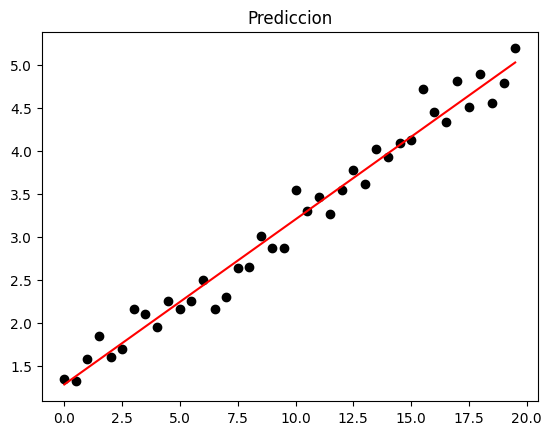

In [ ]:
# 6. Visualizamos nuestra predicción
plt.scatter(x, y, label = 'data', color= 'black')
plt.plot(x, prediccion_entrenamiento, label = 'predicted', color = 'red')
plt.title('Prediccion')
plt.show()

# Clase 2. Modelo de regresión lineal múltiple

En este ejercicio se genera un conjunto de datos sintético para representar un caso de regresión múltiple. A diferencia de la regresión lineal simple, donde se utiliza una única variable predictora, aquí la variable objetivo y depende de dos variables independientes: x1 y x2.

La función definida sigue la forma:

y=0.3x1	+ 0.7x2 + 1.5 + ruido

Esto permite observar cómo varias variables pueden contribuir simultáneamente a explicar una variable objetivo. El término de ruido gaussiano introduce variabilidad aleatoria, simulando un caso más realista.

## Fase de recolección de datos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Fijamos semilla para reproducibilidad
np.random.seed(42)

# 1. Definimos una función de regresión múltiple
# y = 0.3*x1 + 0.7*x2 + 1.5 + ruido gaussiano

def f_multiple(x1, x2):
    ruido = 0.5 * np.random.randn(x1.shape[0])
    y = 0.3 * x1 + 0.7 * x2 + 1.5 + ruido
    return y

# 2. Generamos dos variables independientes
x1 = np.arange(0, 20, 0.5)
x2 = np.random.uniform(0, 20, len(x1))

# 3. Generamos la variable dependiente
y = f_multiple(x1, x2)

# 4. Creamos un DataFrame para visualizar los datos
data_multiple = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "y": y
})

data_multiple.head()



,x1,x2,y
0,0.0,7.490802,6.736813
1,0.5,19.014286,14.431145
2,1.0,14.639879,12.459188
3,1.5,11.973170,9.720797
4,2.0,3.120373,4.388693


## Fase de exploración (sencilla)

In [ ]:
# 5. Calculamos estadísiticos descriptivos
print(data_multiple.describe())

              x1         x2          y
count  40.000000  40.000000  40.000000
mean    9.750000   9.125313  10.773511
std     5.845226   5.913700   4.551873
min     0.000000   0.411690   2.549078
25%     4.875000   3.660192   7.439927
50%     9.750000   8.720975  10.529888
75%    14.625000  13.803858  14.018079
max    19.500000  19.398197  20.412518


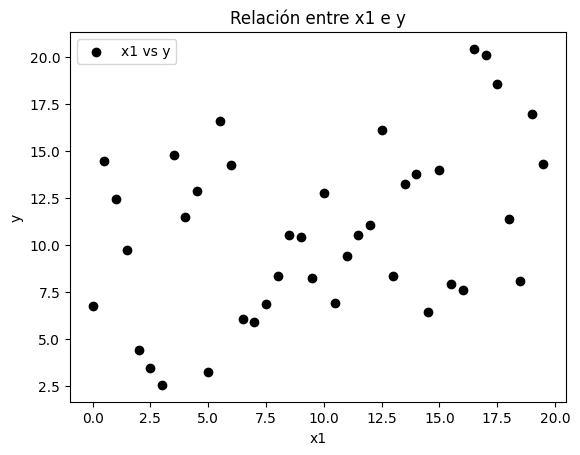

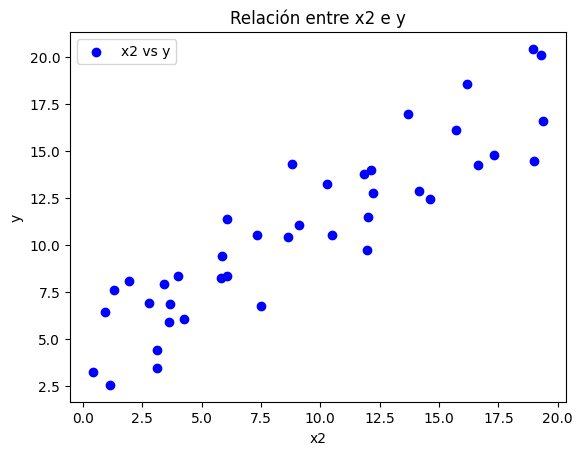

In [ ]:
# 6. Visualizamos la relación de cada variable con y
plt.scatter(x1, y, label='x1 vs y', color='black')
plt.title('Relación entre x1 e y')
plt.xlabel('x1')
plt.ylabel('y')
plt.legend()
plt.show()

plt.scatter(x2, y, label='x2 vs y', color='blue')
plt.title('Relación entre x2 e y')
plt.xlabel('x2')
plt.ylabel('y')
plt.legend()
plt.show()

## Fase de entrenamiento

In [ ]:
from sklearn.linear_model import LinearRegression

X = data_multiple[['x1', 'x2']]
y = data_multiple['y']

model = LinearRegression()
model.fit(X, y)

print(model.intercept_, model.coef_)

1.1869162070042112 [0.32440819 0.70393374]


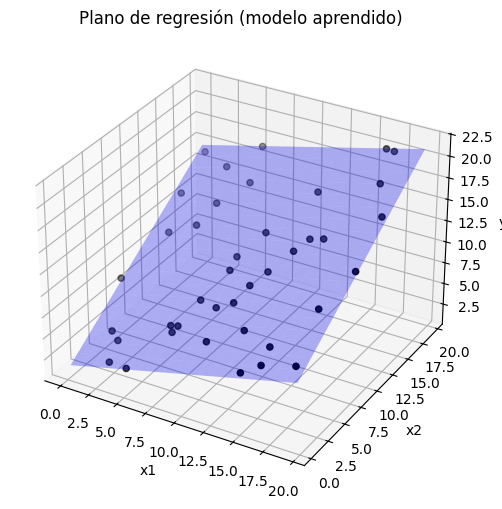

In [ ]:
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# 1. Entrenamos el modelo
X = data_multiple[['x1', 'x2']]
y = data_multiple['y']

model = LinearRegression()
model.fit(X, y)

# 2. Creamos la figura 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# 3. Pintamos los puntos reales
ax.scatter(data_multiple['x1'], data_multiple['x2'], data_multiple['y'], color='black', label='Datos')

# 4. Creamos la malla para el plano
x1_surf, x2_surf = np.meshgrid(
    np.linspace(data_multiple['x1'].min(), data_multiple['x1'].max(), 20),
    np.linspace(data_multiple['x2'].min(), data_multiple['x2'].max(), 20)
)

# 5. Calculamos el plano con el modelo aprendido
y_surf = model.intercept_ + model.coef_[0]*x1_surf + model.coef_[1]*x2_surf

# 6. Dibujamos el plano
ax.plot_surface(x1_surf, x2_surf, y_surf, alpha=0.3, color='blue')

# 7. Etiquetas
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Plano de regresión (modelo aprendido)')

plt.show()

##Fase de validación

In [ ]:
# 1. importamos el cálculo del error cuadrático medio (MSE)
from sklearn.metrics import mean_squared_error

In [ ]:
# 2. predecimos valores "y" para los valores usados en el entrenamiento
prediccion_entrenamiento = model.predict(X)

In [ ]:
# 3. calculamos error cuadrático medio - MSE
mse = mean_squared_error(y_true = y, y_pred = prediccion_entrenamiento)
print("Error cuadrático medio, MSE = " + str(mse))

Error cuadrático medio, MSE = 0.1736395941815587


In [ ]:
# 4. calculamos raiz de MSE - RMSE
rmse = np.sqrt(mse)
print("Raíz del error cuadrático medio, RMSE = " + str(rmse))

Raíz del error cuadrático medio, RMSE = 0.4167008449494177


In [ ]:
# 5. calculamos coeficiente de Determinación- R2
r2_score = model.score(X, y)
print("Coeficiente de Determinación, R2 = " + str(r2_score))

Coeficiente de Determinación, R2 = 0.9914046426870627


## Fase de predicción: en este caso observamos los residuos

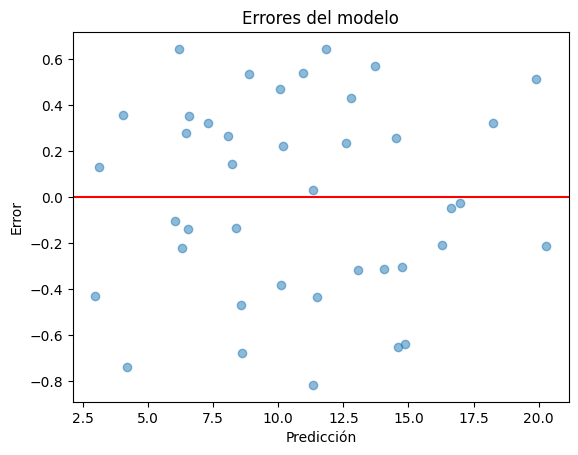

In [ ]:
residuos = y - prediccion_entrenamiento

plt.scatter(prediccion_entrenamiento, residuos, alpha=0.5)
plt.axhline(y=0, color='red')

plt.xlabel("Predicción")
plt.ylabel("Error")
plt.title("Errores del modelo")

plt.show()

Cuando los errores son aleatorios, el modelo está funcionando bien.

Si los errores crecieran con la predicción → heterocedasticidad

Si hubiera forma curva → relación no lineal

Si todos los errores fueran positivos → sesgo